In [1]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/clean_data.csv')
pd.set_option('display.max_colwidth', None)
print("\nFirst Rows:")
df.head()


First Rows:


,Text,Sentiment,Emotion,text_length,word_count
0,"এসব পাছা কবিরের আজাইররা পোস্ট। হেতি ক, ""যদি ভুল করে থাকি!! "" কত্ত বড় হারামজাদি ইতে!! উষ্ঠা মারা উচিত হেতিরে।",Negative,Creepy,110,20
1,জুতা মারি গরুদান মারান!! আপনার আম্মা আব্বার খেলা দেখে কি সিউর হইছিলেন আপনি তাদেরই মেয়ে???,Strongly Negative,Creepy,89,15
2,"সুখে থাকতে ভুতে কিলাই, প্রবাদটা এর কাজের দ্বারা আবারো প্রমানিত। এর অভিযোগের বাস্তবতা ওরে দিয়েই বাস্তবায়ন করা হোক।",Negative,Bullying,113,18
3,তর মাথায় ব্রেন আছে সেটা তুই দেখছস? না দেখলে ভাব্বি গবর আছে,Strongly Negative,Bullying,58,12
4,আপনি কি নাস্তিক..?,Negative,Unbiased,18,3


In [3]:
df.shape

(5635, 5)

In [4]:
import re


# URL Detection
url_pattern = r'http\S+|www\S+'

url_count = df['Text'].str.contains(url_pattern, regex=True).sum()
print(f"Rows containing URLs: {url_count}")


# Actual Emoji Detection
actual_emoji = re.compile(r'[\U0001F300-\U0001FFFF]')

emoji_only_count = df['Text'].apply(
    lambda x: bool(actual_emoji.search(str(x)))
).sum()

print(f"Rows containing actual emojis: {emoji_only_count}")


# Special Punctuation Detection
# (excluding emojis)
punct_pattern = re.compile(
    r'[^\u0980-\u09FF\u0000-\u007F\s\U0001F300-\U0001FFFF]'
)

punct_count = df['Text'].apply(
    lambda x: bool(punct_pattern.search(str(x)))
).sum()

print(f"Rows containing special punctuation/symbols: {punct_count}")

# URL Example
print("\nURL Example:")

url_rows = df[df['Text'].str.contains(url_pattern, regex=True)]

if len(url_rows) > 0:
    print(url_rows['Text'].iloc[0])
else:
    print("No URL found")

# Actual Emoji Example
print("\nActual Emoji Example:")

emoji_rows = df[df['Text'].apply(
    lambda x: bool(actual_emoji.search(str(x)))
)]

if len(emoji_rows) > 0:
    print(emoji_rows['Text'].iloc[0])
else:
    print("No actual emoji found")

# Special Punctuation Example
print("\nSpecial Punctuation Example:")

punct_rows = df[df['Text'].apply(
    lambda x: bool(punct_pattern.search(str(x)))
)]

if len(punct_rows) > 0:
    print(punct_rows['Text'].iloc[0])
else:
    print("No special punctuation found")

Rows containing URLs: 18
Rows containing actual emojis: 31
Rows containing special punctuation/symbols: 2296

URL Example:
সবাই প্রতিবাদ করুন নিচের লিংকে গিয়ে..... https://www.facebook.com/abc4utah/videos/2301600330105127/?fref=mentions

Actual Emoji Example:
খানকিদের লিস্টে তুই সবার উপর থাকবি 🖕🖕🖕🖕🖕

Special Punctuation Example:
এসব পাছা কবিরের আজাইররা পোস্ট। হেতি ক, "যদি ভুল করে থাকি!! " কত্ত বড় হারামজাদি ইতে!!  উষ্ঠা মারা উচিত হেতিরে।


In [25]:
def clean_text(text):

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove emojis
    text = re.sub(r'[\U0001F300-\U0001FFFF]', '', text)

    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)
    text = re.sub(r'[।৷]', '', text)
    # Bengali numbers remove
    text = re.sub(r'[০-৯]', '', text)
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['Text'].apply(clean_text)

# Before vs After
emoji_rows = df[df['Text'].str.contains(r'[\U0001F300-\U0001FFFF]', regex=True)]
idx = emoji_rows.index[0]

print("BEFORE:", df['Text'].iloc[idx])
print("AFTER: ", df['clean_text'].iloc[idx])

BEFORE: খানকিদের লিস্টে তুই সবার উপর থাকবি 🖕🖕🖕🖕🖕
AFTER:  খানকিদের লিস্টে তুই সবার উপর থাকবি


In [6]:
df.head()

,Text,Sentiment,Emotion,text_length,word_count,clean_text
0,"এসব পাছা কবিরের আজাইররা পোস্ট। হেতি ক, ""যদি ভুল করে থাকি!! "" কত্ত বড় হারামজাদি ইতে!! উষ্ঠা মারা উচিত হেতিরে।",Negative,Creepy,110,20,এসব পাছা কবিরের আজাইররা পোস্ট হেতি ক যদি ভুল করে থাকি কত্ত বড় হারামজাদি ইতে উষ্ঠা মারা উচিত হেতিরে
1,জুতা মারি গরুদান মারান!! আপনার আম্মা আব্বার খেলা দেখে কি সিউর হইছিলেন আপনি তাদেরই মেয়ে???,Strongly Negative,Creepy,89,15,জুতা মারি গরুদান মারান আপনার আম্মা আব্বার খেলা দেখে কি সিউর হইছিলেন আপনি তাদেরই মেয়ে
2,"সুখে থাকতে ভুতে কিলাই, প্রবাদটা এর কাজের দ্বারা আবারো প্রমানিত। এর অভিযোগের বাস্তবতা ওরে দিয়েই বাস্তবায়ন করা হোক।",Negative,Bullying,113,18,সুখে থাকতে ভুতে কিলাই প্রবাদটা এর কাজের দ্বারা আবারো প্রমানিত এর অভিযোগের বাস্তবতা ওরে দিয়েই বাস্তবায়ন করা হোক
3,তর মাথায় ব্রেন আছে সেটা তুই দেখছস? না দেখলে ভাব্বি গবর আছে,Strongly Negative,Bullying,58,12,তর মাথায় ব্রেন আছে সেটা তুই দেখছস না দেখলে ভাব্বি গবর আছে
4,আপনি কি নাস্তিক..?,Negative,Unbiased,18,3,আপনি কি নাস্তিক


In [7]:
from sklearn.feature_extraction.text  import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, min_df=2, token_pattern=r'\b\S{3,}\b', ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
print("Shape:", X.shape)
print("Sample features:", tfidf.get_feature_names_out()[:20])

Shape: (5635, 5000)
Sample features: ['অংশ' 'অংশ দেখেও' 'অক্সিজেন' 'অগ্রিম' 'অতঃপর' 'অতএব' 'অতপর' 'অতীতের'
 'অতুলনীয়' 'অত্যন্ত' 'অত্যন্ত ক্ষমাশীল' 'অত্যাচার' 'অথচ' 'অথব' 'অদেখ'
 'অদ্ভুত' 'অধিকার' 'অধিকার নাই' 'অধিকার নেই' 'অনন্ত']


In [8]:
print(tfidf.get_feature_names_out())

['অংশ' 'অংশ দেখেও' 'অক্সিজেন' ... 'হয়েছ তার' 'হয়েছ ধন্যবাদ' 'হয়েছিল']


# **Sentiment Classification**

In [9]:
from sklearn.preprocessing import LabelEncoder

le_sentiment = LabelEncoder()
y_sentiment = le_sentiment.fit_transform(df['Sentiment'])

print("Sentiment Classes:", le_sentiment.classes_)
print("Sample labels:", y_sentiment[:5])

Sentiment Classes: ['Negative' 'Neutral' 'Positive' 'Strongly Negative' 'Strongly Positive']
Sample labels: [0 3 0 3 0]


In [10]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_sentiment,
    test_size=0.2,
    random_state=42,
    stratify=y_sentiment
)

print("Train size:", X_train_s.shape)
print("Test size:", X_test_s.shape)

Train size: (4508, 5000)
Test size: (1127, 5000)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train_s)

y_pred_s = model.predict(X_test_s)

print(classification_report(y_test_s, y_pred_s,
      target_names=le_sentiment.classes_))

                   precision    recall  f1-score   support

         Negative       0.54      0.73      0.62       263
          Neutral       0.44      0.35      0.39       196
         Positive       0.51      0.56      0.53       242
Strongly Negative       0.85      0.69      0.76       231
Strongly Positive       0.55      0.46      0.50       195

         accuracy                           0.57      1127
        macro avg       0.58      0.56      0.56      1127
     weighted avg       0.58      0.57      0.57      1127



In [12]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(max_iter=1000)
svm_model.fit(X_train_s, y_train_s)

y_pred_svm_s = svm_model.predict(X_test_s)

print(classification_report(y_test_s, y_pred_svm_s,
      target_names=le_sentiment.classes_))

                   precision    recall  f1-score   support

         Negative       0.59      0.64      0.61       263
          Neutral       0.42      0.36      0.39       196
         Positive       0.51      0.51      0.51       242
Strongly Negative       0.78      0.74      0.76       231
Strongly Positive       0.45      0.49      0.47       195

         accuracy                           0.56      1127
        macro avg       0.55      0.55      0.55      1127
     weighted avg       0.56      0.56      0.56      1127



# **Emotion Classification**

In [13]:
le_emotion = LabelEncoder()
y_emotion = le_emotion.fit_transform(df['Emotion'])

print("Emotion Classes:", le_emotion.classes_)
print("Sample labels:", y_emotion[:5])

Emotion Classes: ['Bullying' 'Creepy' 'Joyful' 'Surprise' 'Unbiased']
Sample labels: [1 1 0 0 4]


In [14]:
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X, y_emotion,
    test_size=0.2,
    random_state=42,
    stratify=y_emotion
)

print("Train size:", X_train_e.shape)
print("Test size:", X_test_e.shape)

Train size: (4508, 5000)
Test size: (1127, 5000)


In [15]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_e, y_train_e)

y_pred_e = model.predict(X_test_e)

print(classification_report(y_test_e, y_pred_e,
      target_names=le_emotion.classes_))

              precision    recall  f1-score   support

    Bullying       0.41      0.50      0.45       116
      Creepy       0.84      0.73      0.78       359
      Joyful       0.76      0.66      0.70       323
    Surprise       0.33      0.53      0.41        77
    Unbiased       0.54      0.57      0.55       252

    accuracy                           0.64      1127
   macro avg       0.57      0.60      0.58      1127
weighted avg       0.67      0.64      0.65      1127



In [16]:
svm_model = LinearSVC(max_iter=1000, class_weight='balanced')
svm_model.fit(X_train_e, y_train_e)

y_pred_svm_e = svm_model.predict(X_test_e)

print(classification_report(y_test_e, y_pred_svm_e,
      target_names=le_emotion.classes_))

              precision    recall  f1-score   support

    Bullying       0.41      0.42      0.42       116
      Creepy       0.77      0.77      0.77       359
      Joyful       0.73      0.70      0.72       323
    Surprise       0.39      0.42      0.40        77
    Unbiased       0.54      0.55      0.54       252

    accuracy                           0.64      1127
   macro avg       0.57      0.57      0.57      1127
weighted avg       0.64      0.64      0.64      1127



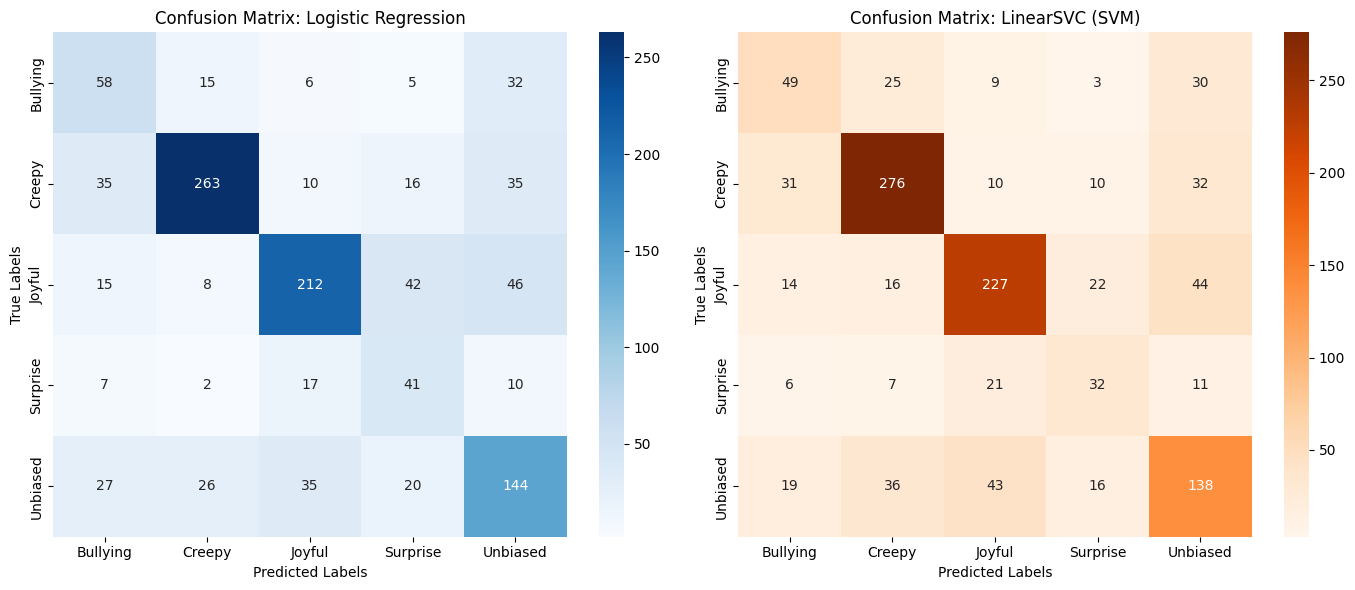

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
cm_lr = confusion_matrix(y_test_e, y_pred_e)
cm_svm = confusion_matrix(y_test_e, y_pred_svm_e)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Logistic Regression Confusion Matrix ---
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_emotion.classes_, yticklabels=le_emotion.classes_)
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

# --- SVM (LinearSVC) Confusion Matrix ---
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=le_emotion.classes_, yticklabels=le_emotion.classes_)
axes[1].set_title('Confusion Matrix: LinearSVC (SVM)')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

plt.tight_layout()
plt.show()

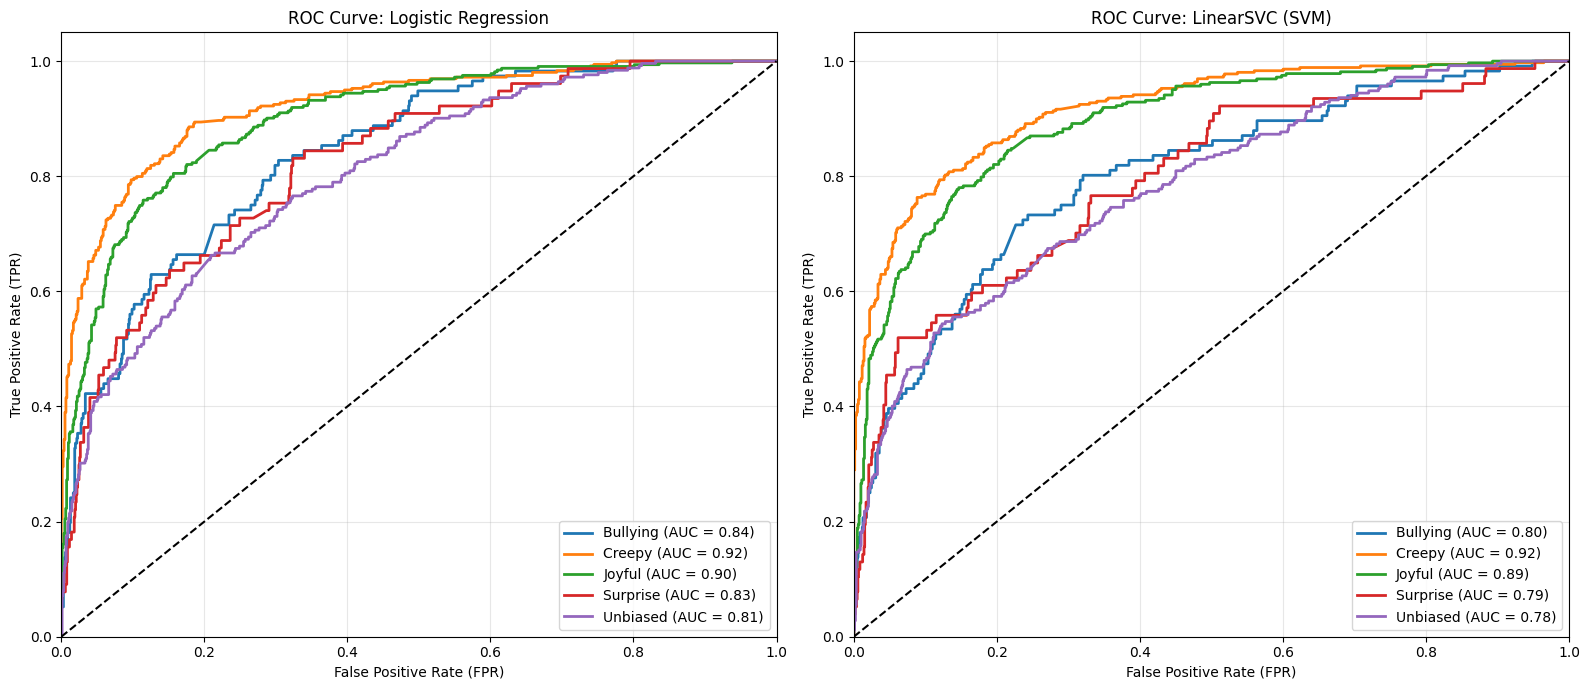

In [23]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = list(le_emotion.classes_)
n_classes = len(classes)
y_test_binarized = label_binarize(y_test_e, classes=np.arange(n_classes))

y_score_lr = model.predict_proba(X_test_e)

y_score_svm = svm_model.decision_function(X_test_e)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Logistic Regression ROC Curve ---
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_lr[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})', lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Curve: Logistic Regression')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# --- SVM (LinearSVC) ROC Curve ---
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_svm[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})', lw=2)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('ROC Curve: LinearSVC (SVM)')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()